In [59]:
%pip install -q pandas
%pip install -q matplotlib
%pip install -q seaborn
%pip install -q openpyxl


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

import sys
sys.path.append("/workspaces/Dark_Buster")
import ler_Arquivo as ler

In [ ]:
# 1. Alocando os valores nas respectivas variáveis
lista1 = ler.ler_arquivo_json(r'/workspaces/Dark_Buster/Data/Lista1_jsons.txt')
lista2 = ler.ler_arquivo_json(r'/workspaces/Dark_Buster/Data/Lista2_jsons.txt')

# 2. Transformando em DataFrames para o gráfico
df_Gemini = pd.DataFrame(lista1)[['manipulative_design', 'url']].assign(Fonte = 'Gemini')
df_Openai = pd.DataFrame(lista2)[['manipulative_design', 'url']].assign(Fonte = 'Openai')

In [78]:
print(f"Gemini: \n{df_Gemini['manipulative_design'].value_counts()} \n")
print(f"Openai: \n{df_Openai['manipulative_design'].value_counts()}")

Gemini: 
manipulative_design
False    22
True     16
Name: count, dtype: int64 

Openai: 
manipulative_design
False    22
True     16
Name: count, dtype: int64


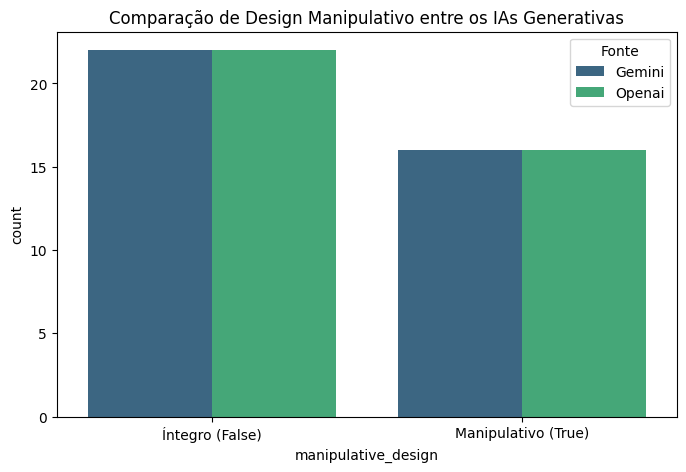

In [ ]:
# 3. Criando o gráfico comparativo
df_final = pd.concat([df_Gemini, df_Openai])

plt.figure(figsize=(8, 5))
sns.countplot(data = df_final, x = 'manipulative_design', hue = 'Fonte', palette = 'viridis')

plt.title("Comparação de Design Manipulativo entre os IAs Generativas")
plt.xticks([0, 1], ['Íntegro (False)', 'Manipulativo (True)'])
plt.show()

In [63]:
df_Resultados = pd.read_excel(r"/workspaces/Dark_Buster/Data/Resultados_esperados.xlsx")
df_Resultados.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   url                           27 non-null     str  
 1   manipulative_design_Buscados  27 non-null     bool 
dtypes: bool(1), str(1)
memory usage: 375.0 bytes


In [64]:
df_Gemini = df_Gemini.merge(df_Resultados, on='url', how='left')
df_Openai = df_Openai.merge(df_Resultados, on='url', how='left')